In [1]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from pathlib import Path 
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DIRECTORY = Path.cwd().parent / "csv"
macro_groups_df= pd.read_csv(DIRECTORY / "macro_community_groups.csv")
macro_groups_df.head(10)

,Macro_Community,DOIs,PaperTitles,Abstracts
0,0,10.1145/3543873.3587570; 10.1109/78.650093; 10...,Graph Embedding for Mapping Interdisciplinary ...,Representation learning is the frst step in au...
1,1,10.1109/ICDM.2017.57; 10.1609/aaai.v31i1.10486...,Topological Recurrent Neural Network for Diffu...,"In this paper, we study the problem of using r..."
2,2,10.1177/030631277500500403; 10.1007/978-1-4899...,Content Analysis of References: Adjunct or Alt...,Complex networks are studied across many field...
3,3,10.1109/TPAMI.2018.2839733; 10.7810/9781988587...,Piecewise Flat Embedding for Image Segmentatio...,We introduce a new multi-dimensional nonlinear...
4,4,10.1007/BF01098364; 10.1007/BF02122549; 10.113...,The maximum clique problem; Optima of dual int...,AbstractThis paper presents some recent result...
5,5,10.1613/jair.953; 10.1145/775047.775126; 10.10...,SMOTE: Synthetic Minority Over-sampling Techni...,An approach to the construction of classifiers...
6,6,10.1126/science.aao0185; 10.1002/asi.21460; 10...,Science of Science; A heuristic approach to au...,National exercises for the evaluation of resea...
7,7,10.1162/tacl_a_00051; 10.18653/v1/d13-1170; 10...,Enriching Word Vectors with Subword Informatio...,"Continuous word representations, trained on la..."
8,8,10.5555/1953048.2078195; 10.3115/1690219.16902...,Scikit-learn: Machine Learning in Python; Dist...,Scikit-learn is a Python module integrating a ...
9,9,10.1093/nar/gkm1001; 10.1093/bioinformatics/bt...,The BioGRID Interaction Database: 2008 update;...,The Biological General Repository for Interact...


In [3]:
# topic_model = BERTopic(embedding_model="all-MiniLM-L6-v2")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
# Dictionary to store topic models and results for each macro community
macro_community_topics = {}


for _, row in macro_groups_df.iterrows():
    macro_id = row['Macro_Community']
    documents = []

    # Parse PaperTitles (semicolon-separated)
    if pd.notna(row['PaperTitles']):
        titles = str(row['PaperTitles']).split('; ')
        documents.extend(titles)

    # Parse Abstracts (if available)
    if 'Abstracts' in row and pd.notna(row['Abstracts']):
        abstracts = str(row['Abstracts']).split('; ')
        # Combine titles with abstracts when both available
        combined_docs = []
        for i, title in enumerate(titles):
            if i < len(abstracts) and abstracts[i]:
                combined_docs.append(f"{title}. {abstracts[i]}")
            else:
                combined_docs.append(title)
        documents = combined_docs

    print(f"Macro Community: {macro_id} - Documents: {len(documents)}")
    
    if len(documents) < 3:
        print("Skipping: Not enough documents for topic modeling")
        continue

    # topics, probs = topic_model.fit_transform(documents)
    # topic_model.get_topic_info()

    # Configure BERTopic for this community
    vectorizer_model = CountVectorizer(stop_words="english", min_df=1, ngram_range=(1, 2), max_features=100)

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        nr_topics='auto',  
        min_topic_size=max(2, len(documents) // 10),  # Adaptive min_topic_size
        calculate_probabilities=False,
        verbose=False
    )

    try:
        topics_result, _ = topic_model.fit_transform(documents)
        topic_info = topic_model.get_topic_info()
        
        # Filter out outlier topic (-1)
        valid_topics = topic_info[topic_info['Topic'] != -1]
        num_topics = len(valid_topics)

        print(f"Topics discovered: {num_topics}")

        if num_topics > 0:
            # Store results
            topic_details = []
            for _, topic_row in valid_topics.iterrows():
                topic_id = topic_row['Topic']
                topic_words = topic_model.get_topic(topic_id)
                keywords = [word for word, _ in topic_words[:5]]
                score = topic_row['Count'] / len(documents)  # Topic prevalence score
                
                topic_details.append({
                    'topic_id': topic_id,
                    'keywords': keywords,
                    'count': topic_row['Count'],
                    'score': score
                })
                
                print(f"  Topic {topic_id}: {', '.join(keywords)} [Score: {score}]")
            
            macro_community_topics[int(macro_id)] = {
                'num_topics': num_topics,
                'topic_details': topic_details,
                'topic_model': topic_model,
                'num_documents': len(documents)
            }
        else:
            print("No distinct topics found")

    except Exception as e:
        print(f"Error processing Macro Community {macro_id}: {e}")
        continue
    

Macro Community: 0 - Documents: 2193
Topics discovered: 2
  Topic 0: text, task, model, word, models [Score: 0.3533971728226174]
  Topic 1: graph, networks, learning, network, graphs [Score: 0.17829457364341086]
Macro Community: 1 - Documents: 229
Topics discovered: 3
  Topic 0: graph, kernels, graphs, matching, kernel [Score: 0.4017467248908297]
  Topic 1: semidefinite, programming, optimization, semidefinite programming, convex [Score: 0.24017467248908297]
  Topic 2: social, information, network, cascade, networks [Score: 0.20087336244541484]
Macro Community: 2 - Documents: 567
Topics discovered: 2
  Topic 0: research, citation, science, journal, scientific [Score: 0.4585537918871252]
  Topic 1: graph, graphs, mml, algorithm, networks [Score: 0.32098765432098764]
Macro Community: 3 - Documents: 242
Topics discovered: 2
  Topic 0: data, topic, model, segmentation, image [Score: 0.8140495867768595]
  Topic 1: education, higher education, higher, research, analysis [Score: 0.18595041322

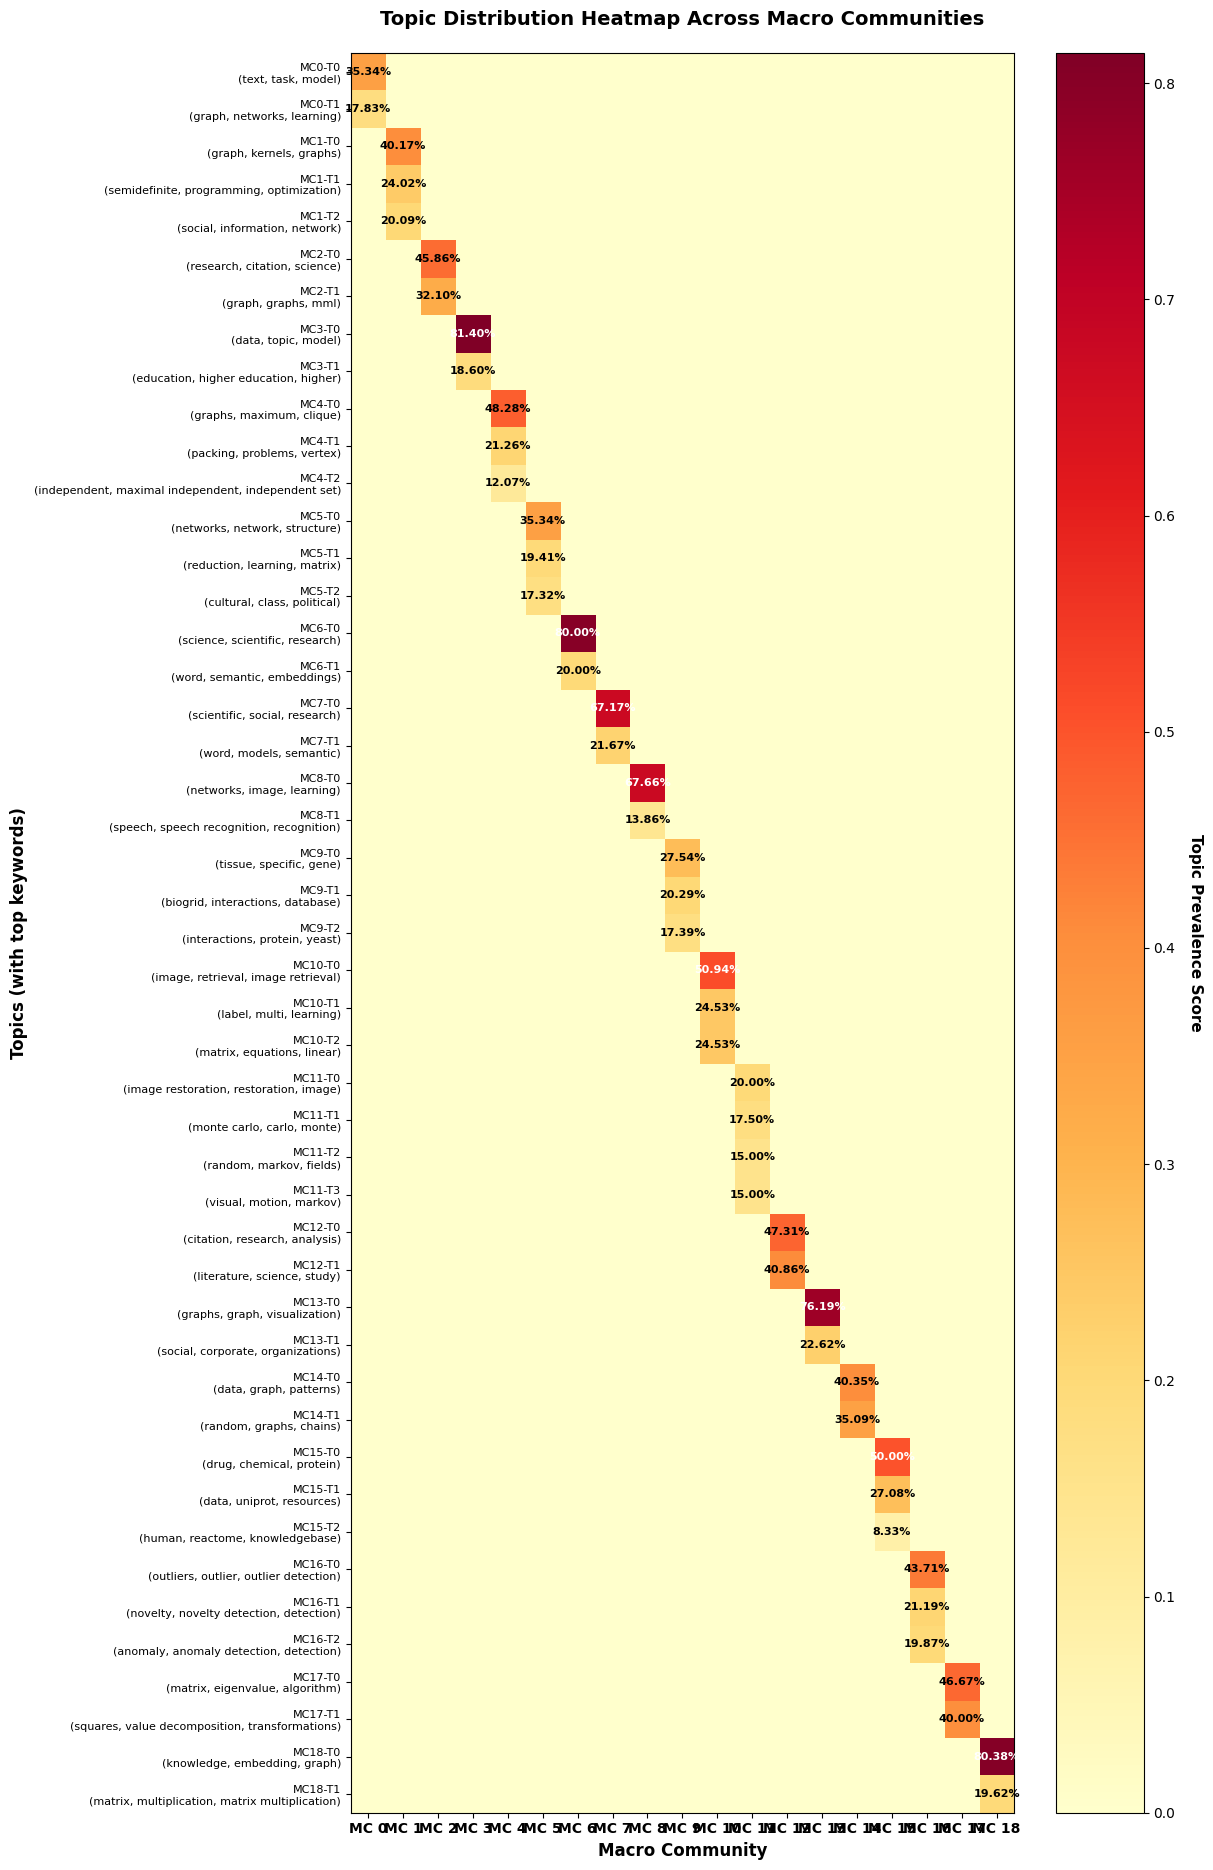

In [4]:
# 3. Heatmap: Topic Distribution Across Macro Communities
# Create a matrix of topic scores

# Collect all unique topic keywords across communities
all_topics_by_community = {}
for macro_id in sorted(macro_community_topics.keys()):
    topic_details = macro_community_topics[macro_id]['topic_details']
    for i, td in enumerate(topic_details):
        topic_label = f"MC{macro_id}-T{td['topic_id']}"
        all_topics_by_community[topic_label] = {
            'macro_id': macro_id,
            'topic_id': td['topic_id'],
            'score': td['score'],
            'keywords': td['keywords'][:3]  # Top 3 keywords
        }

# Create heatmap data
topic_labels = list(all_topics_by_community.keys())
macro_ids_sorted = sorted(macro_community_topics.keys())

heatmap_data = np.zeros((len(topic_labels), len(macro_ids_sorted)))

for i, topic_label in enumerate(topic_labels):
    topic_info = all_topics_by_community[topic_label]
    macro_idx = macro_ids_sorted.index(topic_info['macro_id'])
    heatmap_data[i, macro_idx] = topic_info['score']

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, max(8, len(topic_labels) * 0.4)))

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(macro_ids_sorted)))
ax.set_yticks(np.arange(len(topic_labels)))
ax.set_xticklabels([f'MC {mid}' for mid in macro_ids_sorted], fontsize=10, fontweight='bold')

# Create y-axis labels with keywords
y_labels = []
for topic_label in topic_labels:
    info = all_topics_by_community[topic_label]
    keywords_short = ', '.join(info['keywords'])
    y_labels.append(f"{topic_label}\n({keywords_short})")

ax.set_yticklabels(y_labels, fontsize=8)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Topic Prevalence Score', rotation=270, labelpad=20, fontsize=11, fontweight='bold')

# Add value annotations
for i in range(len(topic_labels)):
    for j in range(len(macro_ids_sorted)):
        if heatmap_data[i, j] > 0:
            text = ax.text(j, i, f'{heatmap_data[i, j]:.2%}',
                          ha="center", va="center", color="black" if heatmap_data[i, j] < 0.5 else "white",
                          fontsize=8, fontweight='bold')

ax.set_xlabel('Macro Community', fontsize=12, fontweight='bold')
ax.set_ylabel('Topics (with top keywords)', fontsize=12, fontweight='bold')
ax.set_title('Topic Distribution Heatmap Across Macro Communities', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [5]:
# 4. Summary Statistics Table
import pandas as pd

summary_data = []
for macro_id in sorted(macro_community_topics.keys()):
    data = macro_community_topics[macro_id]
    topic_details = data['topic_details']
    
    # Calculate statistics
    scores = [td['score'] for td in topic_details]
    counts = [td['count'] for td in topic_details]
    
    summary_data.append({
        'Macro_Community': macro_id,
        'Num_Topics': data['num_topics'],
        'Num_Documents': data['num_documents'],
        'Avg_Topic_Score': np.mean(scores) if scores else 0,
        'Max_Topic_Score': np.max(scores) if scores else 0,
        'Min_Topic_Score': np.min(scores) if scores else 0,
        'Avg_Docs_Per_Topic': np.mean(counts) if counts else 0,
        'Dominant_Topic_Keywords': ', '.join(topic_details[0]['keywords'][:3]) if topic_details else 'N/A'
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*100)
print("SUMMARY STATISTICS: Topic Analysis Across Macro Communities")
print("="*100 + "\n")

# Display formatted table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print(summary_df.to_string(index=False))
print("\n" + "="*100)

# Additional insights
total_topics = summary_df['Num_Topics'].sum()
total_docs = summary_df['Num_Documents'].sum()
avg_topics_per_community = summary_df['Num_Topics'].mean()
avg_docs_per_community = summary_df['Num_Documents'].mean()

print(f"\nOVERALL INSIGHTS:")
print(f"  • Total Topics Discovered: {total_topics}")
print(f"  • Total Documents Analyzed: {total_docs}")
print(f"  • Average Topics per Community: {avg_topics_per_community:.1f}")
print(f"  • Average Documents per Community: {avg_docs_per_community:.1f}")
print(f"  • Community with Most Topics: MC {summary_df.loc[summary_df['Num_Topics'].idxmax(), 'Macro_Community']} ({summary_df['Num_Topics'].max()} topics)")
print(f"  • Community with Most Documents: MC {summary_df.loc[summary_df['Num_Documents'].idxmax(), 'Macro_Community']} ({summary_df['Num_Documents'].max()} docs)")
print("="*100)


SUMMARY STATISTICS: Topic Analysis Across Macro Communities

 Macro_Community  Num_Topics  Num_Documents  Avg_Topic_Score  Max_Topic_Score  Min_Topic_Score  Avg_Docs_Per_Topic               Dominant_Topic_Keywords
               0           2           2193         0.265846         0.353397         0.178295          583.000000                     text, task, model
               1           3            229         0.280932         0.401747         0.200873           64.333333                graph, kernels, graphs
               2           2            567         0.389771         0.458554         0.320988          221.000000           research, citation, science
               3           2            242         0.500000         0.814050         0.185950          121.000000                    data, topic, model
               4           3            174         0.272031         0.482759         0.120690           47.333333               graphs, maximum, clique
               5    